In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from black_scholes.pinn.bs_pinn_nd import BSMaxPINN, BSMinPINN
from config.bs_nd import *

from utility.continuation_prob import compute_continuation_probs, estimate_continuation_value_nd, continuation_normal

## Load models

In [2]:
seeds = range(5)
pinns_max = []
pinns_min = []
for seed in seeds:
    pinn_max = BSMaxPINN(model_config, seed=seed)
    pinn_max.set_params(K, r, sigmas, corr, T, S_mins, S_maxs, compute_interpolators=False)
    pinn_max.load(f'../../models/bs_pinn_nd/maximum/{seed}.pth')
    pinns_max.append(pinn_max)

    pinn_min = BSMinPINN(model_config, seed=seed)
    pinn_min.set_params(K, r, sigmas, corr, T, S_mins, S_maxs, compute_interpolators=False)
    pinn_min.load(f'../../models/bs_pinn_nd/minimum/{seed}.pth')
    pinns_min.append(pinn_min)

## Price plots

### $t$ fixed

In [3]:
resolution = 100
S1 = np.linspace(0, 2, resolution)
S2 = np.linspace(0, 2, resolution)
t = 0.5

def get_prices(mode):
    if mode == 'max':
        pinns = pinns_max
    elif mode == 'min':
        pinns = pinns_min
    else:
        raise ValueError("Invalid mode. Must be 'max' or 'min'.")

    S1_grid, S2_grid = np.meshgrid(S1, S2, indexing='ij')
    t_grid = np.full(S1_grid.shape, t)

    nn_prices_all = np.zeros((resolution, resolution, len(pinns)))
    for k, pinn in enumerate(pinns):
        nn_prices_all[:, :, k] = pinn.predict(t_grid.flatten(), S1_grid.flatten(), S2_grid.flatten()).detach().numpy().reshape(S1_grid.shape)
    nn_prices = np.mean(nn_prices_all, axis=2)
    
    return nn_prices

nn_prices_max = get_prices('max')
nn_prices_min = get_prices('min')

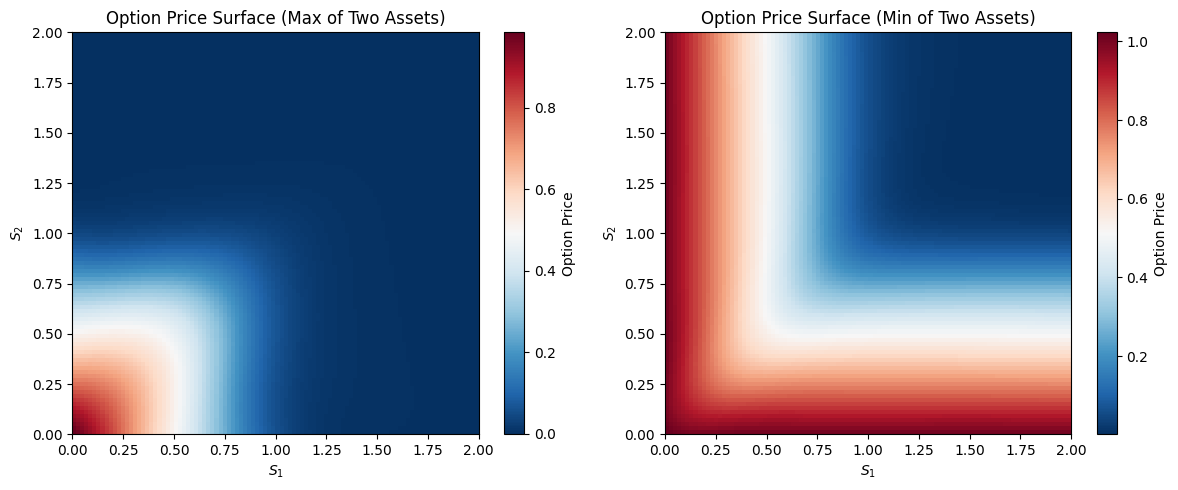

In [4]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(nn_prices_max, extent=(S1.min(), S1.max(), S2.min(), S2.max()), origin='lower', aspect='auto', cmap='RdBu_r')
plt.colorbar(label='Option Price')
plt.xlabel('$S_1$')
plt.ylabel('$S_2$')
plt.title('Option Price Surface (Max of Two Assets)')
plt.subplot(1, 2, 2)
plt.imshow(nn_prices_min, extent=(S1.min(), S1.max(), S2.min(), S2.max()), origin='lower', aspect='auto', cmap='RdBu_r')
plt.colorbar(label='Option Price')
plt.xlabel('$S_1$')
plt.ylabel('$S_2$')
plt.title('Option Price Surface (Min of Two Assets)')
plt.tight_layout()
plt.show()

### $S_1 = S_2$, vary $S_1$ and $t$

In [5]:
resolution = 100
Ss = np.linspace(0, 2, resolution)
ts = np.linspace(0, T, resolution)

def get_prices_diag(mode):
    if mode == 'max':
        pinns = pinns_max
    elif mode == 'min':
        pinns = pinns_min
    else:
        raise ValueError("Invalid mode. Must be 'max' or 'min'.")

    S_grid, t_grid = np.meshgrid(Ss, ts, indexing='ij')

    nn_prices_all = np.zeros((resolution, resolution, len(pinns)))
    for k, pinn in enumerate(pinns):
        nn_prices_all[:, :, k] = pinn.predict(t_grid.flatten(), S_grid.flatten(), S_grid.flatten()).detach().numpy().reshape(S_grid.shape)
    nn_prices = np.mean(nn_prices_all, axis=2)

    return nn_prices

nn_prices_diag_max = get_prices_diag('max')
nn_prices_diag_min = get_prices_diag('min')

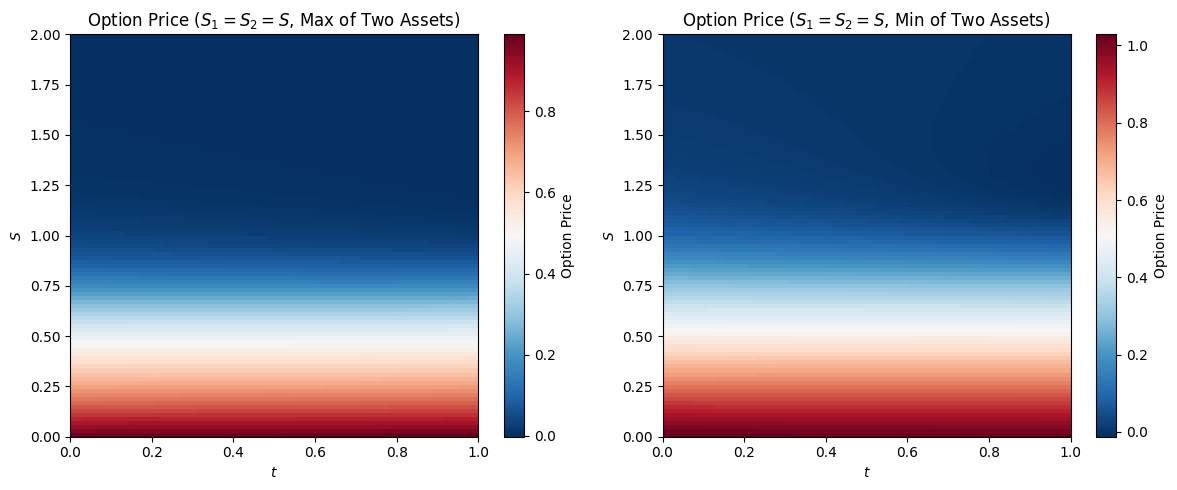

In [6]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(nn_prices_diag_max, extent=(ts.min(), ts.max(), Ss.min(), Ss.max()), origin='lower', aspect='auto', cmap='RdBu_r')
plt.colorbar(label='Option Price')
plt.xlabel('$t$')
plt.ylabel('$S$')
plt.title('Option Price ($S_1 = S_2 = S$, Max of Two Assets)')
plt.subplot(1, 2, 2)
plt.imshow(nn_prices_diag_min, extent=(ts.min(), ts.max(), Ss.min(), Ss.max()), origin='lower', aspect='auto', cmap='RdBu_r')
plt.colorbar(label='Option Price')
plt.xlabel('$t$')
plt.ylabel('$S$')
plt.title('Option Price ($S_1 = S_2 = S$, Min of Two Assets)')
plt.tight_layout()
plt.show()

### Fix $S_1 = S_2 = 1$, vary $t$

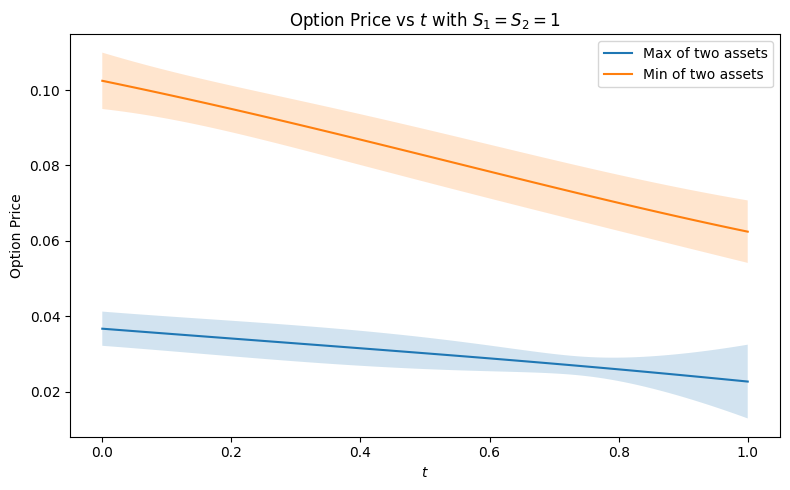

In [7]:
ts_line = np.linspace(0, T, resolution)
S_fixed = 1.0

def get_prices_line(mode):
    if mode == 'max':
        pinns = pinns_max
    elif mode == 'min':
        pinns = pinns_min
    else:
        raise ValueError("Invalid mode. Must be 'max' or 'min'.")

    S_arr = np.full_like(ts_line, S_fixed)
    prices_all = np.zeros((resolution, len(pinns)))
    for k, pinn in enumerate(pinns):
        prices_all[:, k] = pinn.predict(ts_line, S_arr, S_arr).detach().numpy().flatten()
    return prices_all.mean(axis=1), prices_all.std(axis=1)

prices_line_max, std_line_max = get_prices_line('max')
prices_line_min, std_line_min = get_prices_line('min')

plt.figure(figsize=(8, 5))
plt.plot(ts_line, prices_line_max, label='Max of two assets')
plt.fill_between(ts_line, prices_line_max - 1.96 * std_line_max, prices_line_max + 1.96 * std_line_max, alpha=0.2)
plt.plot(ts_line, prices_line_min, label='Min of two assets')
plt.fill_between(ts_line, prices_line_min - 1.96 * std_line_min, prices_line_min + 1.96 * std_line_min, alpha=0.2)
plt.xlabel('$t$')
plt.ylabel('Option Price')
plt.title('Option Price vs $t$ with $S_1 = S_2 = 1$')
plt.legend()
plt.tight_layout()
plt.show()

## Continuation probabilities

In [8]:
resolution = 100
S1s = np.linspace(0, 2, resolution)
S2s = np.linspace(0, 2, resolution)
t = 0.0

intrinsics_max = np.maximum(np.maximum(S1s[:, None], S2s[None, :]) - K, 0)
intrinsics_min = np.maximum(np.minimum(S1s[:, None], S2s[None, :]) - K, 0)

In [ ]:
def plot_continuation_probabilities(pinns, intrinsics):
    nn_continuation_values_all = np.zeros((resolution, resolution, len(pinns)))
    for i, S1 in enumerate(S1s):
        for j, S2 in enumerate(S2s):
            S = torch.tensor([S1, S2], dtype=torch.float32)
            for k, pinn in enumerate(pinns):
                nn_continuation_values_all[i, j, k] = estimate_continuation_value_nd(pinn.model, t, S, r, sigmas, corr, n_paths=100, h=0.01, seed=42)
    
    nn_continuation_values = nn_continuation_values_all.mean(axis=2)
    nn_continuation_values_std = nn_continuation_values_all.std(axis=2)

    nn_continuation_probs_sigmoid = compute_continuation_probs(nn_continuation_values, intrinsics, eps=0.1, one=0.99, shift=0)
    nn_continuation_probs_gaussian = continuation_normal(nn_continuation_values, nn_continuation_values_std, intrinsics)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.title('Continuation Probability (Sigmoid)')
    plt.imshow(nn_continuation_probs_sigmoid, extent=(S1s.min(), S1s.max(), S2s.min(), S2s.max()), origin='lower', aspect='auto', cmap='RdBu_r')
    plt.colorbar(label='Continuation Probability')
    plt.xlabel('S1')
    plt.ylabel('S2')

    plt.subplot(1, 2, 2)
    plt.title('Continuation Probability (Gaussian)')
    plt.imshow(nn_continuation_probs_gaussian, extent=(S1s.min(), S1s.max(), S2s.min(), S2s.max()), origin='lower', aspect='auto', cmap='RdBu_r')
    plt.colorbar(label='Continuation Probability')
    plt.xlabel('S1')
    plt.ylabel('S2')

    plt.tight_layout()
    plt.show()




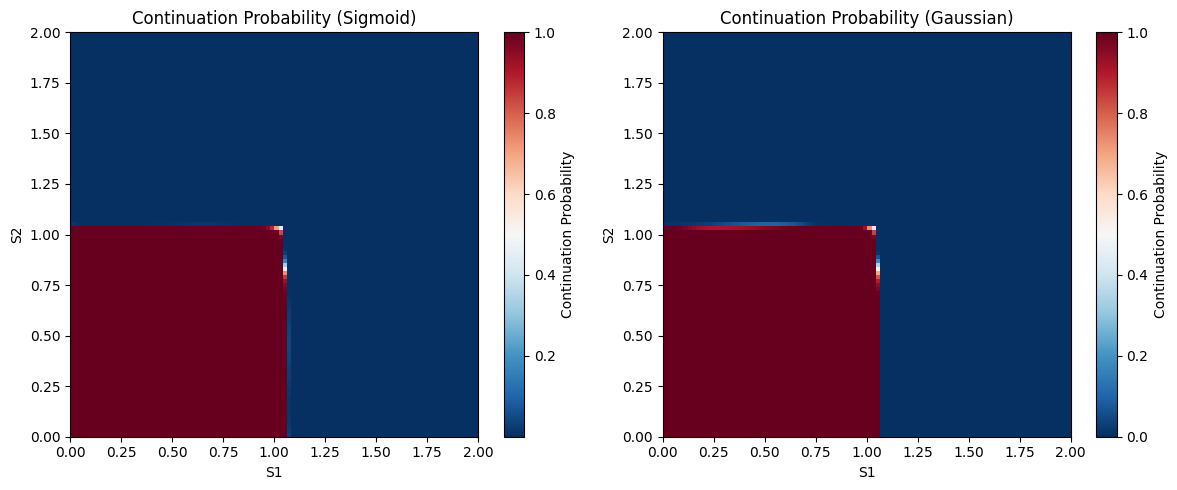

In [16]:
plot_continuation_probabilities(pinns_max, intrinsics_max)

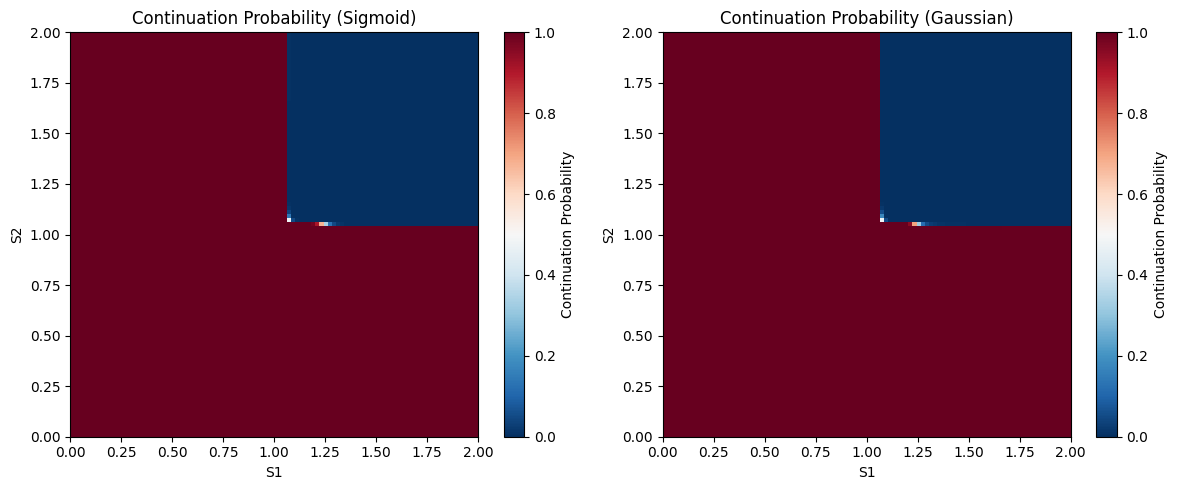

In [14]:
plot_continuation_probabilities(pinns_min, intrinsics_min)